In [1]:
%matplotlib widget

In [2]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels
from FDEM1D import FDEM1D

from matplotlib.colors import LogNorm
plt.style.use('bmh')

L = LogNorm(vmin=0.001, vmax=1)
popts = {'norm': L}

In [3]:

def FDEM3D_topo(geom, model_sig, model_air, height = 0.3):
    """ Simulate Dualem842S in 3D """
    startTime = time.time()
    
    frequency = 9000 # Hertz

    src_x   = geom[0]
    src_z   = geom[1]
    rec2_x  = geom[2]
    rec2_z  = geom[3]
    rec21_x = geom[4]
    rec21_z = geom[5]
    rec4_x  = geom[6]
    rec4_z  = geom[7]
    rec41_x = geom[8]
    rec41_z = geom[9]
    rec8_x  = geom[10]
    rec8_z  = geom[11]
    rec81_x = geom[12]
    rec81_z = geom[13]
    alpha   = geom[14]
    
    # Define sources geometry
    # source = [x, y, z, azimuth, dip]
    Hsource_coords = [src_x, 0, src_z, 0, 90 + math.degrees(alpha)]
    Vsource_coords = [src_x, 0, src_z, 90, 0 + math.degrees(alpha)]
   # Psource_coords = Hsource_coords
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsource_coords)
    Vsource = emg3d.TxMagneticPoint(Vsource_coords)
   # Psource = emg3d.TxMagneticPoint(Psource_coords)

    # Define receivers
    Hrec2 = [rec2_x, 0, rec2_z, 0, 90 + math.degrees(alpha)]
    Vrec2 = [rec2_x, 0, rec2_z, 90, 0 + math.degrees(alpha)]
    Prec2 = [rec21_x, 0, rec21_z, 0, 0 + math.degrees(alpha)]
    Prec2_p = [rec21_x, 0, rec21_z, 0, 90 + math.degrees(alpha)]

    Hrec4 = [rec4_x, 0, rec4_z, 0, 90 + math.degrees(alpha)]
    Vrec4 = [rec4_x, 0, rec4_z, 90, 0 + math.degrees(alpha)]
    Prec4 = [rec41_x, 0, rec41_z, 0, 0 + math.degrees(alpha)]
    Prec4_p = [rec41_x, 0, rec41_z, 0, 90 + math.degrees(alpha)]

    Hrec8 = [rec8_x, 0, rec8_z, 0, 90 + math.degrees(alpha)]
    Vrec8 = [rec8_x, 0, rec8_z, 90, 0 + math.degrees(alpha)]
    Prec8 = [rec81_x, 0, rec81_z, 0, 0 + math.degrees(alpha)]
    Prec8_p = [rec81_x, 0, rec81_z, 0, 90 + math.degrees(alpha)]

    print('Hsource:', Hsource_coords)
    print('Vsource:', Vsource_coords)
    print('Hrec2:', Hrec2)
    print('Vrec2:', Vrec2)
    print('Prec2:', Prec2)
    print('Prec2_p:', Prec2_p)
    print('Hrec4:', Hrec4)
    print('Vrec4:', Vrec4)
    print('Prec4:', Prec4)
    print('Prec4_p:', Prec4_p)
    print('Hrec8:', Hrec8)
    print('Vrec8:', Vrec8)
    print('Prec8:', Prec8)
    print('Prec8_p:', Prec8_p)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = model_sig, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = model_sig, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = model_air, source = Vsource, frequency = frequency)
    
    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = model_sig, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec2 = Hfield_H.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec2_p = Hfield_H_p.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec2_s = H_Hrec2 - H_Hrec2_p

    # For total field Hsource
    H_Hrec4 = Hfield_H.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec4_p = Hfield_H_p.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec4_s = H_Hrec4 - H_Hrec4_p

    # For total field Hsource
    H_Hrec8 = Hfield_H.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec8_p = Hfield_H_p.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec8_s = H_Hrec8 - H_Hrec8_p
    
    # For total field Vsource
    H_Vrec2 = Hfield_V.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec2_p = Hfield_V_p.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec2_s = H_Vrec2 - H_Vrec2_p

    # For total field Vsource
    H_Vrec4 = Hfield_V.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec4_p = Hfield_V_p.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec4_s = H_Vrec4 - H_Vrec4_p

    # For total field Vsource
    H_Vrec8 = Hfield_V.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec8_p = Hfield_V_p.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec8_s = H_Vrec8 - H_Vrec8_p
    
    # For total field Psource
    H_Prec2 = Hfield_H.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec2_p_xz = Hfield_H_p.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec2_s = H_Prec2 - H_Prec2_p_xz
    # Primary field Psource in zz direction
    H_Prec2_p = Hfield_H_p.get_receiver(Prec2_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec4 = Hfield_H.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec4_p_xz = Hfield_H_p.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec4_s = H_Prec4 - H_Prec4_p_xz
    # Primary field Psource in zz direction
    H_Prec4_p = Hfield_H_p.get_receiver(Prec4_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec8 = Hfield_H.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec8_p_xz = Hfield_H_p.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec8_s = H_Prec8 - H_Prec8_p_xz
    # Primary field Psource in zz direction
    H_Prec8_p = Hfield_H_p.get_receiver(Prec8_p)*(2j * np.pi * frequency * mu_0) 
    
    # Calculate output components OP and IP
    print('getting output components')
    #OUT = []
    # Horizontal coplanar
    op_h2 = (H_Hrec2_s/H_Hrec2_p).imag.amp()
    ip_h2 = (H_Hrec2_s/H_Hrec2_p).real.amp()

    op_h4 = (H_Hrec4_s/H_Hrec4_p).imag.amp()
    ip_h4 = (H_Hrec4_s/H_Hrec4_p).real.amp()

    op_h8 = (H_Hrec8_s/H_Hrec8_p).imag.amp()
    ip_h8 = (H_Hrec8_s/H_Hrec8_p).real.amp()

    # Vertical coplanar
    op_v2 = (H_Vrec2_s/H_Vrec2_p).imag.amp()
    ip_v2 = (H_Vrec2_s/H_Vrec2_p).real.amp()

    op_v4 = (H_Vrec4_s/H_Vrec4_p).imag.amp()
    ip_v4 = (H_Vrec4_s/H_Vrec4_p).real.amp()

    op_v8 = (H_Vrec8_s/H_Vrec8_p).imag.amp()
    ip_v8 = (H_Vrec8_s/H_Vrec8_p).real.amp()
    
    # Perpendicular
    op_p2 = (H_Prec2_s/H_Prec2_p).imag.amp()
    ip_p2 = (H_Prec2_s/H_Prec2_p).real.amp()

    op_p4 = (H_Prec4_s/H_Prec4_p).imag.amp()
    ip_p4 = (H_Prec4_s/H_Prec4_p).real.amp()

    op_p8 = (H_Prec8_s/H_Prec8_p).imag.amp()
    ip_p8 = (H_Prec8_s/H_Prec8_p).real.amp()

    # src x pos | rec x pos | midpoint | data
    OUT = {'geom' : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
           'src_x' : [Hsource_coords[0], Hsource_coords[0], Hsource_coords[0],
                      Vsource_coords[0], Vsource_coords[0], Vsource_coords[0],
                      Hsource_coords[0], Hsource_coords[0], Hsource_coords[0]],
           'rec_x' : np.hstack((rec2_x, rec4_x, rec8_x, 
                                rec2_x, rec4_x, rec8_x, 
                                rec21_x, rec41_x, rec81_x)),
           'midpx' : np.hstack(( src_x + 1, src_x + 2, src_x + 4,
                                 src_x + 1, src_x + 2, src_x + 4,
                                 src_x + 1.05, src_x + 2.05, src_x + 4.05 )),
           'op' : np.hstack((op_h2, op_h4, op_h8, op_v2, op_v4, op_v8, op_p2, op_p4, op_p8)),
           'ip' : np.hstack((ip_h2, ip_h4, ip_h8, ip_v2, ip_v4, ip_v8, ip_p2, ip_p4, ip_p8)) 
          }

    OUT = pd.DataFrame(OUT)

    print(OUT)
               
    endTime = time.time()
    print('Done in', (endTime - startTime), 'seconds!')
    return OUT, Efield_H

# Create sinusoidal model

# Parameters
x_start = 0      # Starting x value
x_end = 3.50      # Ending x value
num_points = 350  # Number of points
initial_freq = 1  # Initial frequency in Hz
freq_increase = 0.5  # Frequency increase rate

# Generate x values
xx = np.linspace(x_start, x_end, num_points)

# Define frequency as a function of x
freq = initial_freq + freq_increase * xx

# Generate y values for the sinusoidal line with increasing frequency
y = np.sin(2 * np.pi * freq * xx)/4 -0.5

x1 = np.linspace(1, num_points+31, num_points+30, endpoint=False)
x0 = np.linspace(0, num_points+30, num_points+30, endpoint=False)

z0 = np.zeros_like(x0)

z1 = np.zeros_like(x1)
z1[:15] = y[0]
z1[15:len(y)+15] = y
z1[len(y)+15:] = y[-1]


h_a = np.zeros_like(z0) 
h_1 = z1 + 1
s_a = np.ones_like(x0) * 1 /1e6
s_1 = np.ones_like(x0) * 200/1000
s_2 = np.ones_like(x0) * 20/1000

model_topo = np.array([h_a, h_1, s_a, s_1, s_2]).T
model = np.array([h_1, s_1, s_2]).T

dz = 0
dx = x1 - x0

h0 = 0.3 # height of the midpoint 

alphas = np.arctan(-dz/dx)

mdp_z = -h_a + (h0 / np.cos(alphas))
mdp_x = x0 + h0 * np.sin(alphas)

npos = len(h_a)
nlay = 2

depths = np.zeros((npos, nlay))
depths[:,0] = -h_a
depths[:,1] = -h_a - h_1

src_x = mdp_x * np.cos(alphas)  - 4
src_z = mdp_z + (mdp_x - src_x)*np.sin(alphas)

rec2_x = mdp_x * np.cos(alphas)  - 2
rec2_z = mdp_z + (mdp_x - rec2_x)*np.sin(alphas)

rec21_x = mdp_x * np.cos(alphas)  - 1.9
rec21_z = mdp_z + (mdp_x - rec21_x)*np.sin(alphas)

rec4_x = mdp_x.copy()
rec4_z = mdp_z.copy()

rec41_x = mdp_x * np.cos(alphas)  + 0.1
rec41_z = mdp_z + (mdp_x - rec41_x)*np.sin(alphas)

rec8_x = mdp_x * np.cos(alphas)  + 4
rec8_z = mdp_z + (mdp_x - rec8_x)*np.sin(alphas)

rec81_x = mdp_x * np.cos(alphas)  + 4.1
rec81_z = mdp_z + (mdp_x - rec81_x)*np.sin(alphas)

geom = np.array([src_x, src_z, rec2_x, rec2_z, rec21_x, rec21_z, rec4_x, rec4_z, rec41_x, rec41_z, rec8_x, rec8_z, rec81_x, rec81_z, alphas]).T

def FDEM3D_line_topo(geom, depths=depths, model=model, frequency=9000, popts=popts):

    src_x = geom[0]
    src_z = geom[1]
    
    sig_bg = 20/1000
    sig_air = 1/1e6

    npos = len(model)

    # Define mesh
    mesh = emg3d.construct_mesh(frequency = frequency,
                             properties = [sig_bg, sig_air],
                             center = [src_x, 0, src_z],
                             mapping='Conductivity',
                             domain = ([src_x - 10, src_x + 10], [-10, 10], [src_z-4, src_z+4]),
                             min_width_limits = [0.2, 0.2, 0.05], # changed z from 0.1 to 0.2
                             center_on_edge=False,
                             stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1.1,1.5]}, 
                             lambda_from_center=True,
                             lambda_factor=3, 
                       #      cell_numbers=[512, 128, 128]
                       #      max_buffer = 300000,
                       #      min_width_pps = 5
                             )

    print('src x:', src_x)
    print('src z:', src_z)
    #print('rec x:', [rec2_x, rec21_x, rec4_x, rec41_x, rec8_x, rec81_x])
    #print('rec z:', [rec2_z, rec4_z, rec8_z])
    #print('alpha:', math.degrees(alpha))
    print(mesh)
    
    # Define air layer
    sig_x = np.ones(mesh.n_cells)*sig_air # empty array to be populated
    sig_air = np.ones(mesh.n_cells)*sig_air # air array
    
    # Populate grid
    
    # Fill before position 0
    
    x = mesh.cell_centers[:,0] <=0
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[0,0]) & (mesh.cell_centers[:,2] > depths[0,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[0,1]) 
    
    sig_x[x*y*z_lay1] = model[0,1] # First layer sigma
    sig_x[x*y*z_lay2] = model[0,2] # Second layer sigma
    
    for p in range(npos):
       
        x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
        y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
        z_lay1 = (mesh.cell_centers[:,2] < depths[p,0]) & (mesh.cell_centers[:,2] > depths[p,1])
        z_lay2 = (mesh.cell_centers[:,2] < depths[p,1]) 
    
        sig_x[x*y*z_lay1] = model[p,1]
        sig_x[x*y*z_lay2] = model[p,2]
    
    # fill after position npos
    
    x = (mesh.cell_centers[:,0] > npos) 
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[-1,0]) & (mesh.cell_centers[:,2] > depths[-1,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[-1,1]) 
    
    sig_x[x*y*z_lay1] = model[-1,1]
    sig_x[x*y*z_lay2] = model[-1,2]
    
    #  4. Define models
    
    Model = emg3d.Model(mesh, 
                     property_x = sig_x,
                     mapping = 'Conductivity')
    
    Model_air = emg3d.Model(mesh,
                         property_x = sig_air,
                         mapping = 'Conductivity')

    data_3D, Field = FDEM3D_topo(geom, 
                          Model, 
                          Model_air)



    return data_3D, mesh, Model, Field

(-1.0, 0.0)

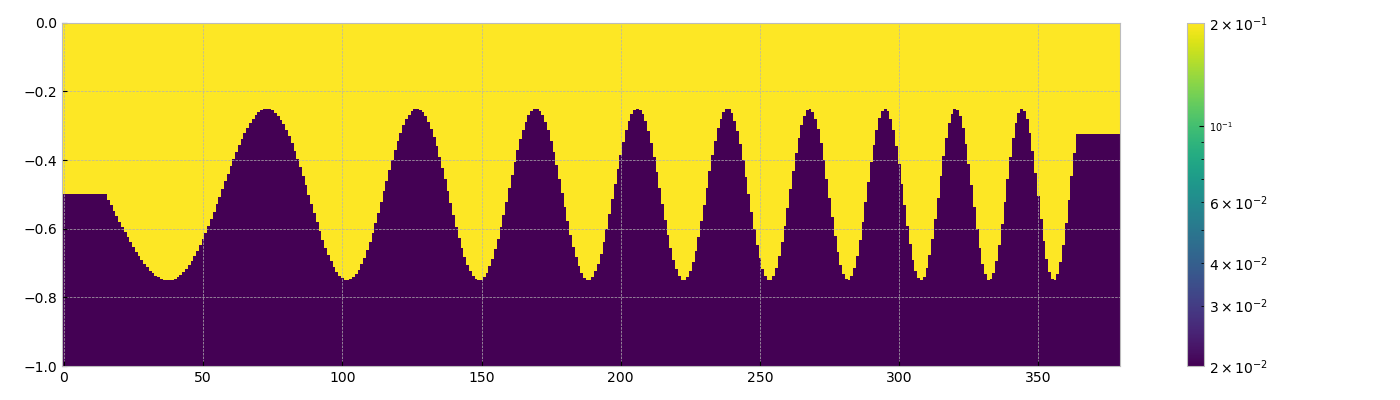

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

showStitchedModels(model, zMax= 2, ax=ax)
plt.tight_layout()

ax.set_ylim([-1,0])

In [5]:
n= 20

data_3D, mesh, Model, Field = FDEM3D_line_topo(geom[n])

src x: 16.0
src z: 0.3

  TensorMesh: 2,359,296 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    192   -108,928.39    141,420.87      0.20 32,460.48    1.30
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z    128   -102,804.37    152,795.95      0.05 49,990.98    1.49


Hsource: [16.0, 0, 0.3, 0, 90.0]
Vsource: [16.0, 0, 0.3, 90, 0.0]
Hrec2: [18.0, 0, 0.3, 0, 90.0]
Vrec2: [18.0, 0, 0.3, 90, 0.0]
Prec2: [18.1, 0, 0.3, 0, 0.0]
Prec2_p: [18.1, 0, 0.3, 0, 90.0]
Hrec4: [20.0, 0, 0.3, 0, 90.0]
Vrec4: [20.0, 0, 0.3, 90, 0.0]
Prec4: [20.1, 0, 0.3, 0, 0.0]
Prec4_p: [20.1, 0, 0.3, 0, 90.0]
Hrec8: [24.0, 0, 0.3, 0, 90.0]
Vrec8: [24.0, 0, 0.3, 90, 0.0]
Prec8: [24.1, 0, 0.3, 0, 0.0]
Prec8_p: [24.1, 0, 0.3, 0, 90.0]
Solving sources...
getting magnetic fields...
magnetic field at receivers...
getting output 

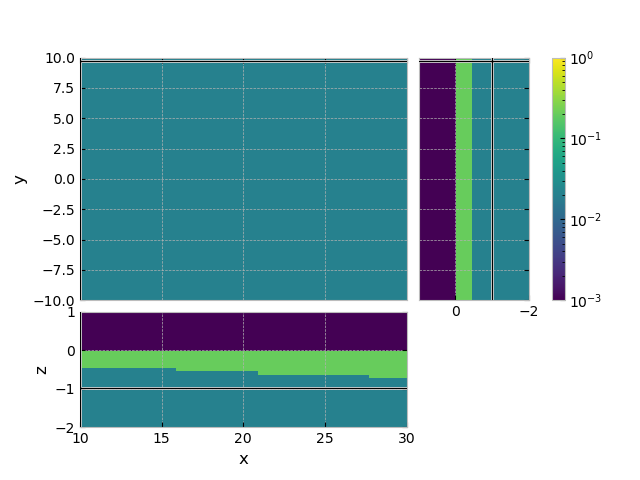

In [6]:
mesh.plot_3d_slicer(
    Model.property_x, xslice=10, yslice=10, zslice = -1, pcolor_opts=popts, xlim=[n-10,n+10], ylim=[-10,10], zlim=[-2,1],
)

fig = plt.gcf()
ax = fig.get_children()
ax[1].plot(rec8_x[n], 0, 'bv')
ax[1].plot(rec4_x[n], 0, 'bv')
ax[1].plot(rec2_x[n], 0, 'bv')

ax[2].plot(rec8_x[n], rec8_z[n], 'bv')
ax[2].plot(rec4_x[n], rec4_z[n], 'bv')
ax[2].plot(rec2_x[n], rec2_z[n], 'bv')

ax[3].plot(rec8_z[n], 0, 'bv')
ax[3].plot(rec4_z[n], 0, 'bv')
ax[3].plot(rec2_z[n], 0, 'bv')

ax[1].plot(src_x[n], 0, 'r*')
ax[2].plot(src_x[n], src_z[n], 'r*')
ax[3].plot(src_z[n], 0, 'r*')

ax[1].plot([src_x[n], rec8_x[n]], [0, 0], ':')
ax[2].plot([src_x[n], rec8_x[n]], [src_z[n], rec8_z[n]], ':')
ax[3].plot([src_z[n], rec8_z[n]], [0, 0], ':')


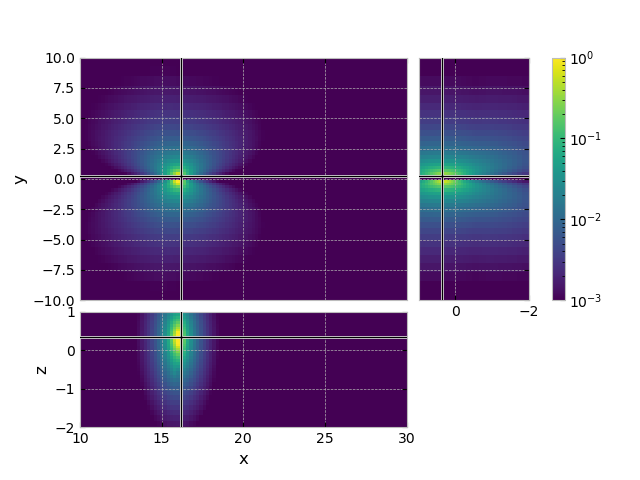

In [24]:
mesh.plot_3d_slicer(
        Field.fx.ravel('F'), view='abs', v_type='Ex', xlim=[n-10,n+10], ylim=[-10,10], zlim=[-2,1], pcolor_opts=popts
        
)

fig = plt.gcf()
ax = fig.get_children()

ax[1].plot(rec8_x[n], 0, 'bv')
ax[1].plot(rec4_x[n], 0, 'bv')
ax[1].plot(rec2_x[n], 0, 'bv')

ax[2].plot(rec8_x[n], rec8_z[n], 'bv')
ax[2].plot(rec4_x[n], rec4_z[n], 'bv')
ax[2].plot(rec2_x[n], rec2_z[n], 'bv')

ax[3].plot(rec8_z[n], 0, 'bv')
ax[3].plot(rec4_z[n], 0, 'bv')
ax[3].plot(rec2_z[n], 0, 'bv')

ax[1].plot(src_x[n], 0, 'r*')
ax[2].plot(src_x[n], src_z[n], 'r*')
ax[3].plot(src_z[n], 0, 'r*')

ax[1].plot([src_x[n], rec8_x[n]], [0, 0], ':')
ax[2].plot([src_x[n], rec8_x[n]], [src_z[n], rec8_z[n]], ':')
ax[3].plot([src_z[n], rec8_z[n]], [0, 0], ':')